In [4]:
import requests
from urllib.robotparser import RobotFileParser

BASE_URL = "https://remoteok.com"
SCRAPE_URL = "https://remoteok.com/remote-dev-jobs"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36"
}


response = requests.get(f"{BASE_URL}/robots.txt", headers=headers)
print(response.text)

User-agent: *
Crawl-delay: 1
Allow: /
Sitemap: https://remoteok.com/sitemap.xml

User-agent: AhrefsBot
Disallow: /


Disallow: /*?action=get_jobs
Disallow: /*?*action=get_jobs
Disallow: /*?*&action=get_jobs
Disallow: /*?*&action=get_jobs&*


User-agent: SemrushBot
Disallow: /

User-agent: SemrushBot-BA
Disallow: /

# Majestic - SEO
User-agent: MJ12bot
Disallow: /

User-agent: Screaming Frog SEO Spider
Disallow: /

# Seozoom - SEO
User-Agent: ZoomBot
Disallow: /

User-agent: sistrix
Disallow: /

User-agent: serpstatbot
Disallow: /

User-agent: MozBot
Disallow: /

# https://moz.com/help/moz-procedures/crawlers/rogerbot
User-agent: rogerbot
Disallow: /

# https://moz.com/help/moz-procedures/crawlers/dotbot
User-agent: dotbot
Disallow: /

User-agent: DataForSeoBot
Disallow: /

Disallow: /l/
Disallow: /*ou-tout-autre*
Disallow: /*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*



In [15]:
import requests
import time

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36"
}

url = "https://remoteok.com/api"

response = requests.get(url, headers=headers)
time.sleep(1)

data = response.json()

print(f"NO OF OBJECTS: {len(data)}")

print(data[1])  # data[0] بيكون legal notice مش وظيفة

NO OF OBJECTS: 99
{'slug': 'remote-sales-enablement-analyst-broker-api-alpaca-1130642', 'id': '1130642', 'epoch': 1772708407, 'date': '2026-03-05T11:00:07+00:00', 'company': 'Alpaca', 'company_logo': '', 'position': 'Sales Enablement Analyst Broker API', 'tags': ['analyst', 'crypto', 'training', 'support', 'financial', 'investment', 'fintech', 'api', 'operations', 'sales', 'non tech'], 'description': '<p><strong>Who We Are:</strong></p>\n<p>Alpaca is a US-headquartered self-clearing broker-dealer and brokerage infrastructure for stocks, ETFs, options, crypto, fixed income, 24/5 trading, and more. Our&nbsp;<a href="https://alpaca.markets/blog/alpaca-raises-150-million-at-a-1-15b-valuation-to-build-the-global-standard-for-brokerage-infrastructure/">recent Series D funding round</a> brought our total investment to over $320 million, fueling our ambitious vision.</p>\n<p>Amongst our subsidiaries, Alpaca is a licensed financial services company, serving hundreds of financial institutions ac

In [16]:
data[1].keys()

dict_keys(['slug', 'id', 'epoch', 'date', 'company', 'company_logo', 'position', 'tags', 'description', 'location', 'apply_url', 'salary_min', 'salary_max', 'logo', 'url'])

In [19]:
import pandas as pd


jobs = data[1:]
df = pd.DataFrame(jobs)

df = df[["position", "company", "location", "tags", "date"]]


print(df.head())
print(f"\nشكل البيانات: {df.shape}")

                              position   company  \
0  Sales Enablement Analyst Broker API    Alpaca   
1                      Account Manager  DataKind   
2                            Tech lead  Ringbook   
3                      DevOps Engineer      MEMX   
4                       Lab Technician     ICEYE   

                                    location  \
0                                              
1                                              
2                                              
3  Georgia; Singapore; Sri Lanka; Uzbekistan   
4                                    Finland   

                                                tags  \
0  [analyst, crypto, training, support, financial...   
1  [manager, technical, director, travel, educati...   
2                      [engineer, senior, dev, exec]   
3  [system, security, software, devops, operation...   
4                                                 []   

                        date  
0  2026-03-05T11:00:07+00:00  

In [26]:
df

,position,company,location,tags,date
0,Sales Enablement Analyst Broker API,Alpaca,Remote,"[analyst, crypto, training, support, financial...",2026-03-05
1,Account Manager,DataKind,Remote,"[manager, technical, director, travel, educati...",2026-03-04
2,Tech lead,Ringbook,Remote,"[engineer, senior, dev, exec]",2026-03-04
3,DevOps Engineer,MEMX,Georgia; Singapore; Sri Lanka; Uzbekistan,"[system, security, software, devops, operation...",2026-03-04
4,Lab Technician,ICEYE,Finland,[],2026-03-04
...,...,...,...,...,...
93,Talent Acquisition Partner,vCluster Labs,Munich,"[consultant, architect, technical, support, de...",2026-02-21
94,Vice President of Engagement Transformation,Solera Health,Remote,"[architect, growth, leader, strategy, manageme...",2026-02-21
95,Director AI Engineering,Lantern,USA,"[director, content, engineering]",2026-02-21
96,Full Stack Software Engineer II,Technergetics,Remote,"[software, hr, system, director, code, engineer]",2026-02-21


In [23]:
df['date'] = pd.to_datetime(df['date']).dt.date

In [25]:
df['location']=df['location'].replace('','Remote')
df['location']=df['location'].fillna('Remote')

In [27]:
df.head()

,position,company,location,tags,date
0,Sales Enablement Analyst Broker API,Alpaca,Remote,"[analyst, crypto, training, support, financial...",2026-03-05
1,Account Manager,DataKind,Remote,"[manager, technical, director, travel, educati...",2026-03-04
2,Tech lead,Ringbook,Remote,"[engineer, senior, dev, exec]",2026-03-04
3,DevOps Engineer,MEMX,Georgia; Singapore; Sri Lanka; Uzbekistan,"[system, security, software, devops, operation...",2026-03-04
4,Lab Technician,ICEYE,Finland,[],2026-03-04


In [30]:
all_tags = df['tags'].explode()
skill_counts = all_tags.value_counts()
print(skill_counts.head(10))

tags
senior         37
technical      28
engineer       28
support        25
growth         24
lead           22
engineering    22
manager        21
management     18
sales          16
Name: count, dtype: int64


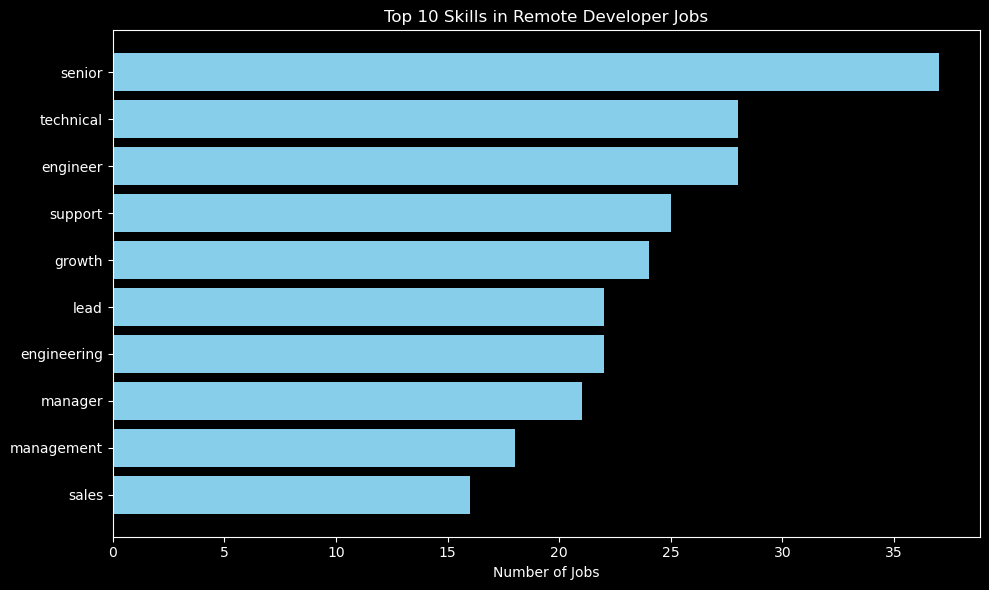

In [33]:
import matplotlib.pyplot as plt
top_skills = skill_counts.head(10)
plt.style.use("dark_background")
plt.figure(figsize=(10, 6))
plt.barh(top_skills.index, top_skills.values, color='skyblue')
plt.xlabel('Number of Jobs')
plt.title('Top 10 Skills in Remote Developer Jobs')
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

In [37]:
city_jobs=df[df['location']!="Remote"].copy()
print(f" City Jobs number : {len(city_jobs)}")
print(city_jobs["location"].unique())

 City Jobs number : 45
['Georgia; Singapore; Sri Lanka; Uzbekistan' 'Finland'
 'United States - East Coast' 'Seattle, Washington' 'United States'
 'Reston, VA' 'Bellevue' 'Singapore' 'Warsaw'
 'Germany - Remote; United Kingdom - Remote' 'Slovakia'
 'San Francisco, CA' 'Denver, CO - Remote'
 'Boulder/Denver, New York City, or Boston' 'U. S.'
 'United States (Remote)' 'Remote - Santo Domingo' 'Dallas, TX' 'BC'
 'Mexico City' 'India' 'United Kingdom' 'Asia' 'Turkey' 'Culver City'
 'Anywhere' 'Any city' 'DC or NYC' 'Long Beach, California' 'Bozeman'
 'Toronto' 'Ogema,MN' 'Buenos Aires' 'Trenton, New Jersey' 'Munich' 'USA']


In [40]:
exclude = ["Anywhere", "Any city", "Remote", "United States", 
           "U. S.", "USA", "United States (Remote)", "Asia"]
city_jobs = city_jobs[~city_jobs['location'].isin(exclude)]

city_jobs = city_jobs.assign(location=city_jobs["location"].str.split(";")).explode("location")

city_jobs["location"] = city_jobs["location"].str.strip()

print(f" City Jobs number after filtering : {len(city_jobs)}")
print(city_jobs["location"].unique())


 City Jobs number after filtering : 35
['Georgia' 'Singapore' 'Sri Lanka' 'Uzbekistan' 'Finland'
 'United States - East Coast' 'Seattle, Washington' 'Reston, VA'
 'Bellevue' 'Warsaw' 'Germany - Remote' 'United Kingdom - Remote'
 'Slovakia' 'San Francisco, CA' 'Denver, CO - Remote'
 'Boulder/Denver, New York City, or Boston' 'Remote - Santo Domingo'
 'Dallas, TX' 'BC' 'Mexico City' 'India' 'United Kingdom' 'Turkey'
 'Culver City' 'DC or NYC' 'Long Beach, California' 'Bozeman' 'Toronto'
 'Ogema,MN' 'Buenos Aires' 'Trenton, New Jersey' 'Munich']


In [42]:

city_jobs = city_jobs[~city_jobs["location"].str.contains(
    "Remote|or |/|East Coast|BC|DC|Ogema", case=False
)]


city_jobs["location"] = city_jobs["location"].str.split(",").str[0].str.strip()

print(f"City Jobs number after filtering: {len(city_jobs)}")
print(city_jobs["location"].unique())

City Jobs number after filtering: 26
['Georgia' 'Singapore' 'Sri Lanka' 'Uzbekistan' 'Finland' 'Seattle'
 'Reston' 'Bellevue' 'Warsaw' 'Slovakia' 'San Francisco' 'Dallas'
 'Mexico City' 'India' 'United Kingdom' 'Turkey' 'Culver City'
 'Long Beach' 'Bozeman' 'Toronto' 'Buenos Aires' 'Trenton' 'Munich']


In [43]:
city_jobs

,position,company,location,tags,date
3,DevOps Engineer,MEMX,Georgia,"[system, security, software, devops, operation...",2026-03-04
3,DevOps Engineer,MEMX,Singapore,"[system, security, software, devops, operation...",2026-03-04
3,DevOps Engineer,MEMX,Sri Lanka,"[system, security, software, devops, operation...",2026-03-04
3,DevOps Engineer,MEMX,Uzbekistan,"[system, security, software, devops, operation...",2026-03-04
4,Lab Technician,ICEYE,Finland,[],2026-03-04
11,Senior Open Source Intelligence Analyst,Concentric Advisors,Seattle,"[analyst, embedded, security, training, consul...",2026-03-04
17,Cloud Architect,Accenture Federal Services,Reston,"[architect, design, security, training, techni...",2026-03-03
18,Contract Senior Gameplay Animator,ArenaNet,Bellevue,"[design, game, technical, developer, animator,...",2026-03-03
19,AI Data Specialist Chinese Simplified,RWS TrainAI,Singapore,"[support, content]",2026-03-03
20,AI Data Specialist Polish,RWS TrainAI,Warsaw,"[support, content]",2026-03-03


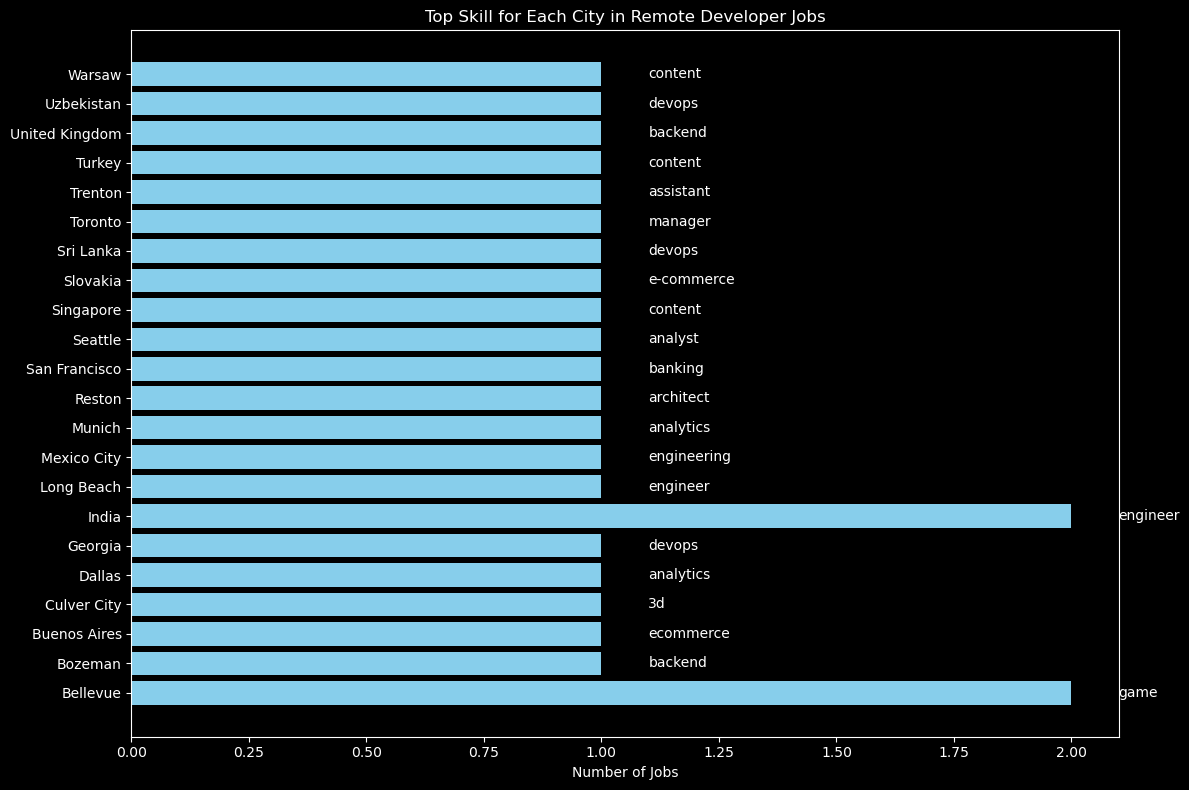

In [51]:
city_skills = city_jobs.explode("tags")
city_skills_counts = city_skills.groupby(["location", "tags"]).size().reset_index(name="count")
top_city_skills = city_skills_counts.loc[city_skills_counts.groupby("location")["count"].idxmax()]


plt.figure(figsize=(12, 8))
plt.barh(top_city_skills["location"], top_city_skills["count"], color='skyblue')
for i, (skill, count) in enumerate(zip(top_city_skills["tags"], top_city_skills["count"])):
    plt.text(count + 0.1, i, skill, va="center", color="white")
plt.xlabel('Number of Jobs')
plt.title('Top Skill for Each City in Remote Developer Jobs')

plt.tight_layout()
plt.show()



In [59]:

role_tags = ["engineer", "manager", "developer", "analyst", 
             "designer", "director", "scientist", "architect", 
             "lead", "consultant"]

all_tags_series = df["tags"].explode()
role_counts = all_tags_series[all_tags_series.isin(role_tags)].value_counts()

print(role_counts)

tags
engineer      28
lead          22
manager       21
director       7
designer       6
analyst        4
architect      4
developer      3
consultant     1
Name: count, dtype: int64


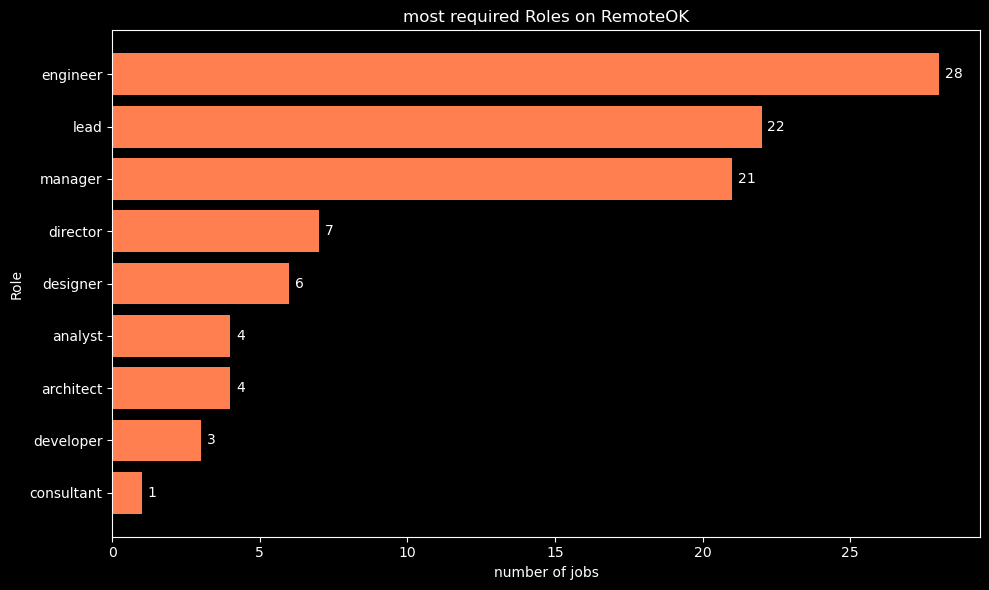

In [63]:

plt.figure(figsize=(10, 6))
plt.barh(role_counts.index, role_counts.values, color="coral")

for i, (role, count) in enumerate(zip(role_counts.index, role_counts.values)):
    plt.text(count + 0.2, i, str(count), va="center", color="white")

plt.xlabel("number of jobs")
plt.ylabel("Role")
plt.title("most required Roles on RemoteOK")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()